# **Binary Classification on Tabular Data - Predicting Heart Disease**

## Dependencies

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Reading Dataset

In [2]:
keras.utils.set_random_seed(42)
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [3]:
df.shape

(303, 14)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


## Normalizing Dataset and can check baseline accuracy

In [5]:
df.target.value_counts(normalize=True, dropna=False)

,proportion
target,
0,0.726073
1,0.273927


## Separating Categorical and Numerical Variables

In [6]:
categorical_variables = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'ca', 'thal']
numerics = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope']
# outof 14 variables, we differentiate between categorical variables and numerical.
# numerical=normalize, categorical=one-hot-encode

## One-hot encoding categorical variables

In [7]:
df = pd.get_dummies(df, columns = categorical_variables, dtype = np.int64)

In [8]:
df.shape

(303, 30)

## Separating Test-Train data

In [9]:
test_df = df.sample(frac = 0.2, random_state=42)
train_df = df.drop(test_df.index)

In [10]:
train_df.shape

(242, 30)

In [11]:
test_df.shape

(61, 30)

## Normalizing numerical Variables

In [12]:
means = train_df[numerics].mean()

In [13]:
sd = train_df[numerics].std()

In [14]:
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


In [15]:
sd

,0
age,9.059861
trestbps,18.012789
chol,48.485377
thalach,23.132298
oldpeak,1.169729
slope,0.632783


In [16]:
train_df[numerics] = (train_df[numerics] - means)/sd
test_df[numerics] = (test_df[numerics] - means)/sd

In [17]:
train_df[numerics]

,age,trestbps,chol,thalach,oldpeak,slope
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825
...,...,...,...,...,...,...
297,0.191107,-0.388383,0.051306,-0.250982,0.143072,0.646494
298,-0.250401,-0.776996,-1.248055,1.737580,-0.882807,0.646494
299,-1.243793,0.000229,1.948786,-0.596819,1.681890,0.646494
301,-0.691909,-0.110803,0.195680,0.008396,-0.882807,-0.933825


## Separating Input and Output variables

In [18]:
train = train_df.to_numpy()
test = test_df.to_numpy()

In [19]:
train_X = np.delete(train, 6, axis=1)
test_X = np.delete(test, 6, axis=1)

In [20]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [21]:
train_y = train[:, 6]
test_y = test[:, 6]

In [22]:
train_y.shape, test_y.shape

((242,), (61,))

## NN Layers

In [23]:
num_columns = train_X.shape[1]

input = keras.Input(shape=(num_columns,))

h = keras.layers.Dense(16, activation="relu", name="Hidden")(input)
output = keras.layers.Dense(1, activation="sigmoid", name="Output")(h)
model = keras.Model(input, output)

In [24]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

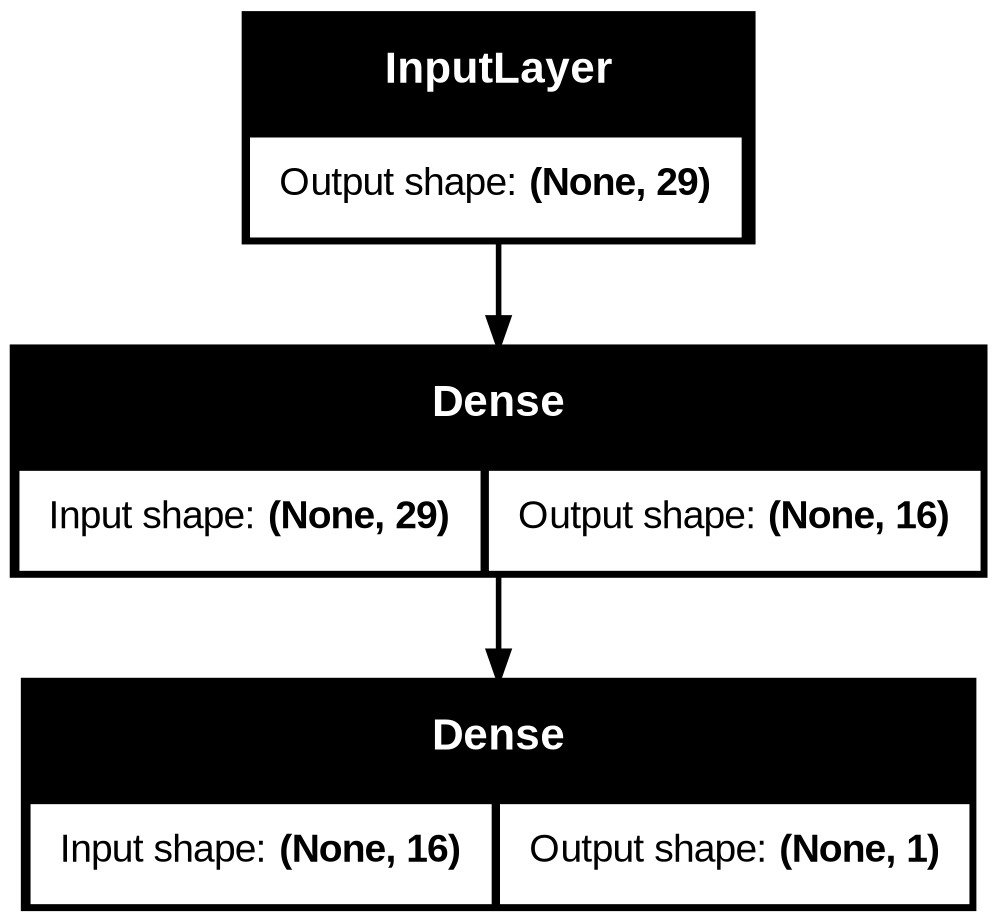

In [25]:
keras.utils.plot_model(model, show_shapes=True)

## Setting up optimizer and loss function

In [26]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Model Fitting

In [28]:
history = model.fit(train_X, train_y, epochs = 300, batch_size = 32, verbose = 1, validation_split=0.2)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.5596 - loss: 0.7154 - val_accuracy: 0.5918 - val_loss: 0.6891
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6062 - loss: 0.6826 - val_accuracy: 0.6122 - val_loss: 0.6697
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6321 - loss: 0.6586 - val_accuracy: 0.6122 - val_loss: 0.6530
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6528 - loss: 0.6376 - val_accuracy: 0.6122 - val_loss: 0.6372
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6736 - loss: 0.6181 - val_accuracy: 0.6531 - val_loss: 0.6225
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6995 - loss: 0.5995 - val_accuracy: 0.6939 - val_loss: 0.6088
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7358 - loss: 0.5822 - val_accuracy: 0.6939 - val_loss: 0.5959
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7513 - loss: 0.5658 - val_accuracy: 0.7143 - val_loss

In [30]:
history_dict = history.history
history_dict.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

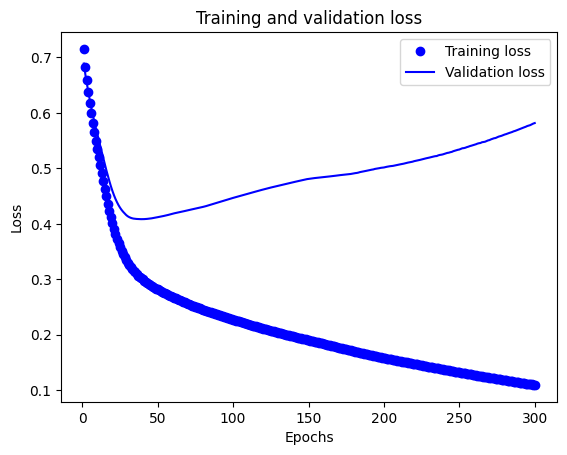

In [31]:
loss_values = history_dict["loss"]
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values)+1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

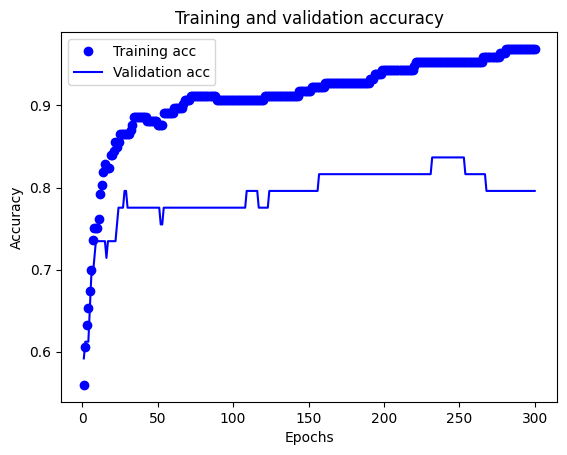

In [32]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Model Evaluation

In [33]:
model.evaluate(test_X, test_y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.8361 - loss: 0.4810


[0.48100942373275757, 0.8360655903816223]